# 03 - Concern Text and Preprocessing

## Objective
The purpose of this notebook is to transform raw review text into a structured concern-aware dataset.

For each review, we want to identify:
- which skin concerns are mentioned
- whether the product helped that concern
- whether the product worsened that concern
- whether the concern is only mentioned as background context

## Why this notebook matters
The final recommendation system should not only detect product sentiment.
It must understand:
- what skin problem the user has
- whether a product helps or harms that problem
- which skin types are associated with the review

## Output files
This notebook will generate:
1. `review_text_features.parquet`
2. `review_concern_level.parquet`

## Approach
We use a hybrid NLP pipeline:
1. light text normalization
2. exact concern phrase matching
3. fuzzy concern matching
4. semantic concern support with sentence embeddings
5. effect direction detection:
   - helped
   - worsened
   - target_only
   - unknown

This notebook is still explainable and debug-friendly.

In [1]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
from typing import List, Dict, Tuple

from difflib import SequenceMatcher

In [2]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load Review-Level Master Data

In [3]:
review_master = pd.read_parquet(PROCESSED_DIR / "review_master.parquet")
print("review_master shape:", review_master.shape)
review_master.head()

review_master shape: (1092743, 43)


,author_id,product_id,product_name_final,brand_name_final,rating,rating_category,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_title,review_text,raw_text,review_text_length,raw_text_length,has_title,skin_tone,eye_color,skin_type,hair_color,price_usd_final,brand_id,loves_count,product_rating,product_review_count,size,variation_type,variation_value,ingredients,limited_edition,new,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,1741593524,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,5,positive,1.0,1.0,2,0,2,2023-02-01,Taught me how to double cleanse!,I use this with the Nudestix “Citrus Clean Balm & Make-Up Melt“ to double cleanse and it has completely changed my skin (for the better). The make-up melt is oil based and removes all of your make...,Taught me how to double cleanse! I use this with the Nudestix “Citrus Clean Balm & Make-Up Melt“ to double cleanse and it has completely changed my skin (for the better). The make-up melt is oil b...,455,488,1,None,brown,dry,black,19.0,7055,177,5.0000,1.0,2.4 oz / 70 ml,Size,2.4 oz / 70 ml,"['Water (Aqua), Dipropylene Glycol, Peg-6 Caprylic/Capric Glycerides, Glycerin, 1,2-Hexanediol, Polyglyceryl-4 Caprate, Butylene Glycol, Carbomer, Propanediol, Tromethamine, Peg-60 Hydrogenated Ca...",0,0,1,0,0,['Clean at Sephora'],Skincare,Cleansers,None,0,NaN,NaN
1,31423088263,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,1,negative,0.0,NaN,0,0,0,2023-03-21,Disappointed,"I bought this lip mask after reading the reviews and the hype. Unfortunately, it did not meet my expectations as vaseline petroleum jelly works way better for me.","Disappointed I bought this lip mask after reading the reviews and the hype. Unfortunately, it did not meet my expectations as vaseline petroleum jelly works way better for me.",162,175,1,None,None,None,None,24.0,6125,1081315,4.3508,16118.0,0.7 oz/ 20 g,Color,Original,"['Diisostearyl Malate, Hydrogenated Polyisobutene, Phyto- Steryl/Isostearyl/Cetyl/Stearyl/Behenyl Dimer Dilinoleate, Hydrogenated Poly(C6-14 Olefin), Polybutene, Microcrystalline Wax / Cera Microc...",0,0,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'Community Favorite', 'Vitamin C', 'Hydrating', 'Good for: Dryness', 'Without Parabens']",Skincare,Lip Balms & Treatments,None,3,24.0,24.0
2,5061282401,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,5,positive,1.0,NaN,0,0,0,2023-03-21,New Favorite Routine,My review title says it all! I get so excited to get into bed and apply this lip mask. I do see a difference because I suffer from dry cracked lips. I drink a lot of water and apply lip balm daily...,New Favorite Routine My review title says it all! I get so excited to get into bed and apply this lip mask. I do see a difference because I suffer from dry cracked lips. I drink a lot of water and...,272,293,1,light,brown,dry,blonde,24.0,6125,1081315,4.3508,16118.0,0.7 oz/ 20 g,Color,Original,"['Diisostearyl Malate, Hydrogenated Polyisobutene, Phyto- Steryl/Isostearyl/Cetyl/Stearyl/Behenyl Dimer Dilinoleate, Hydrogenated Poly(C6-14 Olefin), Polybutene, Microcrystalline Wax / Cera Microc...",0,0,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'Community Favorite', 'Vitamin C', 'Hydrating', 'Good for: Dryness', 'Without Parabens']",Skincare,Lip Balms & Treatments,None,3,24.0,24.0
3,6083038851,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,5,positive,1.0,NaN,0,0,0,2023-03-20,Can't go wrong with any of them,I’ve always loved this formula for a long time. I honestly don’t even use it for night time. I use it as an everyday lip balm. I love the texture. Gummy Bear is my second most favourite scent. Gra...,Can't go wrong with any of them I’ve always loved this formula for a long time. I honestly don’t even use it for night time. I use it as an everyday lip balm. I love the

## 2. Create a Working Copy

We keep the original dataset unchanged and build all text features on a copy.

In [4]:
df = review_master.copy()

## 3. Build the Main Review Text Field

We use `raw_text` if it already exists.
If not, we reconstruct it from `review_title` and `review_text`.

In [5]:
if "raw_text" not in df.columns:
    df["review_title"] = df["review_title"].fillna("").astype(str)
    df["review_text"] = df["review_text"].fillna("").astype(str)

    df["raw_text"] = (
        df["review_title"].str.strip() + " " + df["review_text"].str.strip()
    ).str.strip()

df["raw_text"] = df["raw_text"].fillna("").astype(str)
df = df[df["raw_text"].str.len() > 0].copy()

print("Shape after removing empty raw_text rows:", df.shape)

Shape after removing empty raw_text rows: (1092743, 43)


In [6]:
df[["review_title", "review_text", "raw_text"]].head(5)

,review_title,review_text,raw_text
0,Taught me how to double cleanse!,I use this with the Nudestix “Citrus Clean Balm & Make-Up Melt“ to double cleanse and it has completely changed my skin (for the better). The make-up melt is oil based and removes all of your make...,Taught me how to double cleanse! I use this with the Nudestix “Citrus Clean Balm & Make-Up Melt“ to double cleanse and it has completely changed my skin (for the better). The make-up melt is oil b...
1,Disappointed,"I bought this lip mask after reading the reviews and the hype. Unfortunately, it did not meet my expectations as vaseline petroleum jelly works way better for me.","Disappointed I bought this lip mask after reading the reviews and the hype. Unfortunately, it did not meet my expectations as vaseline petroleum jelly works way better for me."
2,New Favorite Routine,My review title says it all! I get so excited to get into bed and apply this lip mask. I do see a difference because I suffer from dry cracked lips. I drink a lot of water and apply lip balm daily...,New Favorite Routine My review title says it all! I get so excited to get into bed and apply this lip mask. I do see a difference because I suffer from dry cracked lips. I drink a lot of water and...
3,Can't go wrong with any of them,I’ve always loved this formula for a long time. I honestly don’t even use it for night time. I use it as an everyday lip balm. I love the texture. Gummy Bear is my second most favourite scent. Gra...,Can't go wrong with any of them I’ve always loved this formula for a long time. I honestly don’t even use it for night time. I use it as an everyday lip balm. I love the texture. Gummy Bear is my ...
4,A must have !!!,"If you have dry cracked lips, this is a must have. After a few weeks of use I have learned I will always have by my bedside. I thought it was a little expensive but a little goes a long way. It is...","A must have !!! If you have dry cracked lips, this is a must have. After a few weeks of use I have learned I will always have by my bedside. I thought it was a little expensive but a little goes a..."


## 4. Light Text Normalization

We avoid aggressive cleaning because we still need phrase-level context.

This version is useful for:
- embedding
- semantic matching
- local effect detection

In [7]:
def normalize_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [8]:
df["normalized_text"] = df["raw_text"].apply(normalize_text)
df[["raw_text", "normalized_text"]].head(5)

,raw_text,normalized_text
0,Taught me how to double cleanse! I use this with the Nudestix “Citrus Clean Balm & Make-Up Melt“ to double cleanse and it has completely changed my skin (for the better). The make-up melt is oil b...,taught me how to double cleanse! i use this with the nudestix “citrus clean balm & make-up melt“ to double cleanse and it has completely changed my skin (for the better). the make-up melt is oil b...
1,"Disappointed I bought this lip mask after reading the reviews and the hype. Unfortunately, it did not meet my expectations as vaseline petroleum jelly works way better for me.","disappointed i bought this lip mask after reading the reviews and the hype. unfortunately, it did not meet my expectations as vaseline petroleum jelly works way better for me."
2,New Favorite Routine My review title says it all! I get so excited to get into bed and apply this lip mask. I do see a difference because I suffer from dry cracked lips. I drink a lot of water and...,new favorite routine my review title says it all! i get so excited to get into bed and apply this lip mask. i do see a difference because i suffer from dry cracked lips. i drink a lot of water and...
3,Can't go wrong with any of them I’ve always loved this formula for a long time. I honestly don’t even use it for night time. I use it as an everyday lip balm. I love the texture. Gummy Bear is my ...,can't go wrong with any of them i’ve always loved this formula for a long time. i honestly don’t even use it for night time. i use it as an everyday lip balm. i love the texture. gummy bear is my ...
4,"A must have !!! If you have dry cracked lips, this is a must have. After a few weeks of use I have learned I will always have by my bedside. I thought it was a little expensive but a little goes a...","a must have !!! if you have dry cracked lips, this is a must have. after a few weeks of use i have learned i will always have by my bedside. i thought it was a little expensive but a little goes a..."


## 5.Matching-Friendly Clean Text Version

This version is stricter and is used for:
- exact phrase matching
- selective fuzzy matching
- rule-based effect detection later

In [9]:
def clean_text_for_matching(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [10]:
df["clean_text"] = df["normalized_text"].apply(clean_text_for_matching)
df[["normalized_text", "clean_text"]].head(5)

,normalized_text,clean_text
0,taught me how to double cleanse! i use this with the nudestix “citrus clean balm & make-up melt“ to double cleanse and it has completely changed my skin (for the better). the make-up melt is oil b...,taught me how to double cleanse i use this with the nudestix citrus clean balm make up melt to double cleanse and it has completely changed my skin for the better the make up melt is oil based and...
1,"disappointed i bought this lip mask after reading the reviews and the hype. unfortunately, it did not meet my expectations as vaseline petroleum jelly works way better for me.",disappointed i bought this lip mask after reading the reviews and the hype unfortunately it did not meet my expectations as vaseline petroleum jelly works way better for me
2,new favorite routine my review title says it all! i get so excited to get into bed and apply this lip mask. i do see a difference because i suffer from dry cracked lips. i drink a lot of water and...,new favorite routine my review title says it all i get so excited to get into bed and apply this lip mask i do see a difference because i suffer from dry cracked lips i drink a lot of water and ap...
3,can't go wrong with any of them i’ve always loved this formula for a long time. i honestly don’t even use it for night time. i use it as an everyday lip balm. i love the texture. gummy bear is my ...,can t go wrong with any of them i ve always loved this formula for a long time i honestly don t even use it for night time i use it as an everyday lip balm i love the texture gummy bear is my seco...
4,"a must have !!! if you have dry cracked lips, this is a must have. after a few weeks of use i have learned i will always have by my bedside. i thought it was a little expensive but a little goes a...",a must have if you have dry cracked lips this is a must have after a few weeks of use i have learned i will always have by my bedside i thought it was a little expensive but a little goes a long w...


## 6. Concern Dictionary

This dictionary is English-optimized because the review dataset is in English.

Each concern includes:
- direct concern names
- common variants
- user-style expressions
- effect-related expressions

In [11]:
concern_dict = {
    "acne": [
        "acne", "pimple", "pimples", "breakout", "breakouts", "blemish", "blemishes",
        "clogged pores", "zits", "purging", "skin purging",
        "my skin broke out", "made me break out", "caused breakouts",
        "gave me acne", "triggered acne", "caused pimples", "made me breakout"
    ],
    "dryness": [
        "dry", "dryness", "dehydrated", "dehydration", "flaky", "flakiness",
        "tight skin", "parched", "very dry", "super dry",
        "made my skin dry", "dried out my skin", "left my skin dry",
        "dry lips", "dry skin"
    ],
    "oiliness": [
        "oily", "oiliness", "greasy", "shine", "shiny", "excess oil",
        "too oily", "very oily", "super oily",
        "made my skin oily", "left my skin greasy"
    ],
    "sensitivity": [
        "sensitive", "sensitivity", "reactive skin", "reactive",
        "too strong", "harsh", "stung", "stinging", "burning", "burn",
        "irritated", "irritation",
        "made my skin sensitive", "caused irritation", "burned my skin", "stings"
    ],
    "redness": [
        "redness", "flushed", "rosacea",
        "made me red", "turned my skin red", "caused redness",
        "left my skin red"
    ],
    "pores": [
        "pores", "pore", "large pores", "clogged pores",
        "minimize pores", "visible pores", "enlarged pores",
        "reduce pore size"
    ],
    "dark_spots": [
        "dark spot", "dark spots", "hyperpigmentation",
        "post acne marks", "acne marks", "pigmentation",
        "uneven tone", "uneven skin tone", "discoloration"
    ],
    "aging": [
        "fine lines", "wrinkles", "wrinkle", "aging", "anti aging",
        "firming", "loss of elasticity", "mature skin",
        "reduce wrinkles", "smooth fine lines"
    ],
    "dullness": [
        "dull", "dullness", "glow", "radiance",
        "brightening", "brighter skin",
        "lack of glow", "improve radiance", "glowing skin"
    ],
    "texture": [
        "texture", "rough skin", "smooth skin",
        "uneven texture", "bumpy skin",
        "skin texture", "improve texture", "refine texture"
    ]
}

## 7. Flatten the Concern Dictionary

This makes the concern dictionary easier to inspect and debug.

In [12]:
concern_lookup = []

for concern, phrases in concern_dict.items():
    for phrase in phrases:
        concern_lookup.append({
            "concern": concern,
            "phrase": phrase.lower().strip()
        })

concern_lookup = pd.DataFrame(concern_lookup)
concern_lookup.head(20)

,concern,phrase
0,acne,acne
1,acne,pimple
2,acne,pimples
3,acne,breakout
4,acne,breakouts
5,acne,blemish
6,acne,blemishes
7,acne,clogged pores
8,acne,zits
9,acne,purging


## 8. Exact Concern Matching

This is the most interpretable concern extraction layer.
If a phrase clearly appears in the text, we keep it.

In [13]:
def exact_concern_matches(text, concern_dict):
    matches = []

    for concern, phrases in concern_dict.items():
        for phrase in phrases:
            phrase_clean = phrase.lower().strip()
            if phrase_clean in text:
                matches.append((concern, phrase_clean))

    # aynı concern'i birden fazla kez ekleme
    seen = set()
    unique_matches = []
    for c, p in matches:
        if c not in seen:
            unique_matches.append((c, p))
            seen.add(c)

    return unique_matches

In [14]:
df["exact_matches"] = df["clean_text"].apply(
    lambda x: exact_concern_matches(x, concern_dict)
)

df[["clean_text", "exact_matches"]].head(10)

,clean_text,exact_matches
0,taught me how to double cleanse i use this with the nudestix citrus clean balm make up melt to double cleanse and it has completely changed my skin for the better the make up melt is oil based and...,[]
1,disappointed i bought this lip mask after reading the reviews and the hype unfortunately it did not meet my expectations as vaseline petroleum jelly works way better for me,[]
2,new favorite routine my review title says it all i get so excited to get into bed and apply this lip mask i do see a difference because i suffer from dry cracked lips i drink a lot of water and ap...,"[(dryness, dry)]"
3,can t go wrong with any of them i ve always loved this formula for a long time i honestly don t even use it for night time i use it as an everyday lip balm i love the texture gummy bear is my seco...,"[(texture, texture)]"
4,a must have if you have dry cracked lips this is a must have after a few weeks of use i have learned i will always have by my bedside i thought it was a little expensive but a little goes a long w...,"[(dryness, dry)]"
5,great the scent isn t my favourite but it works great i put it on every night before i go to sleep and every morning i wake up with smooth moisturizer and soft packaging is amazing as well,"[(aging, aging)]"
6,dried my lips out and clogged my pores i ll give this stars for nice packaging and lovely scent upon initial application it feels very nice but as i continued to use it i noticed i was getting mor...,"[(acne, pimple), (dryness, dry), (pores, pores), (aging, aging)]"
7,works great i use this at night or while i m putting makeup on love the way i don t have to reapply it during the night definitely a win,[]
8,must have i love this stuff i first had the sample size from a sephora birthday gift and once i had run through it i knew it was a purchase i live in an incredibly dry environment great for macaro...,"[(dryness, dry)]"
9,run to purchase i purchased the sweet candy scent at my local sephora and i am obsessed i will be honest the scent is a bit strong but they re all strongly scented my lips are so soft,[]


## 9. Skip Fuzzy Matching for This Iteration

Fuzzy matching is intentionally disabled in this iteration because:
- it is too slow on the full dataset
- it significantly slows down experimentation
- exact matching + semantic matching are enough for the first stable pipeline

We keep the structure compatible with future fuzzy upgrades,
but for now `fuzzy_matches` will remain empty.

In [15]:
no_exact_mask = df["exact_matches"].apply(len) == 0

print("Rows with no exact matches:", no_exact_mask.sum())
print("No exact match ratio:", round(no_exact_mask.mean(), 4))

Rows with no exact matches: 383282
No exact match ratio: 0.3508


In [16]:
# Initialize fuzzy_matches as empty lists for all rows
df["fuzzy_matches"] = [[] for _ in range(len(df))]

## 10. Rule-Based Concern Layer

We build the rule-based concern layer using exact matches only.

Each review is assigned:
- a list of matched phrases
- a list of extracted concerns

These will be used as the foundation for further semantic enrichment

In [17]:
df["rule_based_matches"] = df["exact_matches"].copy()

In [18]:
def extract_concern_labels(match_tuples):
    return list(set([concern for concern, phrase in match_tuples]))

In [19]:
df["rule_based_concerns"] = df["rule_based_matches"].apply(extract_concern_labels)

df[["clean_text", "exact_matches", "rule_based_concerns"]].head(15)

,clean_text,exact_matches,rule_based_concerns
0,taught me how to double cleanse i use this with the nudestix citrus clean balm make up melt to double cleanse and it has completely changed my skin for the better the make up melt is oil based and...,[],[]
1,disappointed i bought this lip mask after reading the reviews and the hype unfortunately it did not meet my expectations as vaseline petroleum jelly works way better for me,[],[]
2,new favorite routine my review title says it all i get so excited to get into bed and apply this lip mask i do see a difference because i suffer from dry cracked lips i drink a lot of water and ap...,"[(dryness, dry)]",[dryness]
3,can t go wrong with any of them i ve always loved this formula for a long time i honestly don t even use it for night time i use it as an everyday lip balm i love the texture gummy bear is my seco...,"[(texture, texture)]",[texture]
4,a must have if you have dry cracked lips this is a must have after a few weeks of use i have learned i will always have by my bedside i thought it was a little expensive but a little goes a long w...,"[(dryness, dry)]",[dryness]
5,great the scent isn t my favourite but it works great i put it on every night before i go to sleep and every morning i wake up with smooth moisturizer and soft packaging is amazing as well,"[(aging, aging)]",[aging]
6,dried my lips out and clogged my pores i ll give this stars for nice packaging and lovely scent upon initial application it feels very nice but as i continued to use it i noticed i was getting mor...,"[(acne, pimple), (dryness, dry), (pores, pores), (aging, aging)]","[acne, pores, aging, dryness]"
7,works great i use this at night or while i m putting makeup on love the way i don t have to reapply it during the night definitely a win,[],[]
8,must have i love this stuff i first had the sample size from a sephora birthday gift and once i had run through it i knew it was a purchase i live in an incredibly dry environment great for macaro...,"[(dryness, dry)]",[dryness]
9,run to purchase i purchased the sweet candy scent at my local sephora and i am obsessed i will be honest the scent is a bit strong but they re all strongly scented my lips are so soft,[],[]


## 11. Check Rule-Based Coverage

Before moving to semantic matching, we inspect the rule-based concern layer.

In [20]:
rule_based_coverage = (df["rule_based_concerns"].apply(len) > 0).mean()

print("Rule-based concern coverage:", round(rule_based_coverage, 4))

Rule-based concern coverage: 0.6492


In [21]:
rule_based_concern_freq = pd.Series(
    [c for lst in df["rule_based_concerns"] for c in lst]
).value_counts()

rule_based_concern_freq

dryness        231209
sensitivity    174512
oiliness       172870
acne           161651
dullness       121048
aging          105090
texture        100731
pores           65174
redness         41600
dark_spots      30940
Name: count, dtype: int64

<Axes: title={'center': 'Rule-Based Concern Frequency'}>

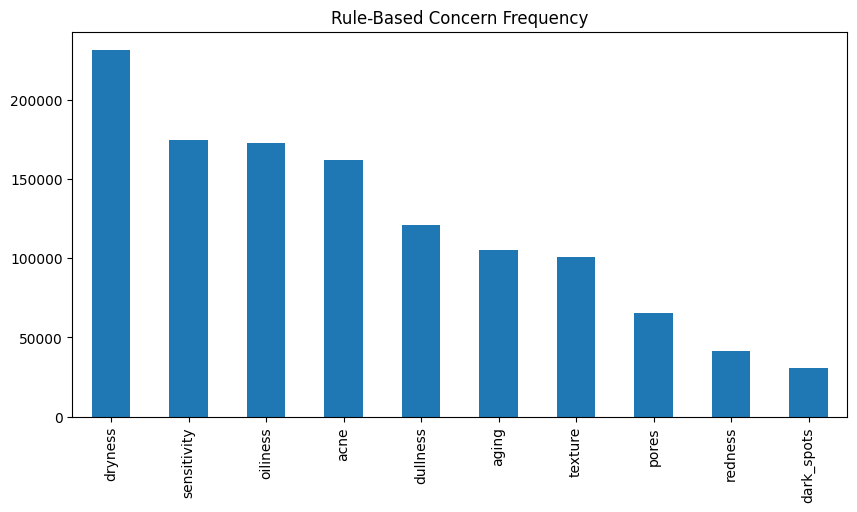

In [22]:
rule_based_concern_freq.plot(kind="bar", figsize=(10, 5), title="Rule-Based Concern Frequency")

## 12. Semantic Matching with Sentence Embeddings

Rule-based matching is precise and interpretable,
but it may miss semantically similar reviews.

We now add a sentence-transformer layer to improve concern recall.

In [23]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [24]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

## 13.Define Concern Prototype Sentences

Each concern is represented by a short prototype sentence.
Review embeddings will be compared against these prototypes.

In [25]:
concern_prototypes = {
    "acne": "This review is about acne, pimples, blemishes, clogged pores, breakouts, or purging.",
    "dryness": "This review is about dryness, dehydration, flakiness, tight skin, dry skin, or dry lips.",
    "oiliness": "This review is about oiliness, greasy skin, shine, or excess oil.",
    "sensitivity": "This review is about irritation, stinging, burning, harshness, or sensitive skin.",
    "redness": "This review is about redness, flushing, rosacea, or skin turning red.",
    "pores": "This review is about pores, visible pores, clogged pores, or pore size.",
    "dark_spots": "This review is about dark spots, pigmentation, acne marks, discoloration, or uneven tone.",
    "aging": "This review is about wrinkles, fine lines, elasticity loss, or aging concerns.",
    "dullness": "This review is about dull skin, lack of glow, brightness, radiance, or brightening.",
    "texture": "This review is about uneven texture, rough skin, bumps, smoothness, or skin texture."
}

In [26]:
concern_names = list(concern_prototypes.keys())
prototype_texts = list(concern_prototypes.values())

prototype_embeddings = embedding_model.encode(
    prototype_texts,
    show_progress_bar=False
)

## 14. Encode Review Texts

We encode the normalized review text to perform semantic matching.
This step may take some time on the full dataset.

In [27]:
review_embeddings = embedding_model.encode(
    df["normalized_text"].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/34149 [00:00<?, ?it/s]

In [28]:
similarity_matrix = cosine_similarity(review_embeddings, prototype_embeddings)
similarity_matrix.shape

(1092743, 10)

## 15. Convert Semantic Similarity into Concern Predictions

We keep concern labels above a similarity threshold.
This threshold can be tuned later if needed.

In [29]:
semantic_threshold = 0.40

In [30]:
semantic_matches = []

for row_idx in range(similarity_matrix.shape[0]):
    row_scores = similarity_matrix[row_idx]
    row_matches = []

    for concern_idx, score in enumerate(row_scores):
        if score >= semantic_threshold:
            row_matches.append((concern_names[concern_idx], float(score)))

    semantic_matches.append(row_matches)

In [31]:
df["semantic_matches"] = semantic_matches
df["semantic_concerns"] = df["semantic_matches"].apply(
    lambda matches: [concern for concern, score in matches]
)

df[["normalized_text", "semantic_matches", "semantic_concerns"]].head(10)

,normalized_text,semantic_matches,semantic_concerns
0,taught me how to double cleanse! i use this with the nudestix “citrus clean balm & make-up melt“ to double cleanse and it has completely changed my skin (for the better). the make-up melt is oil b...,[],[]
1,"disappointed i bought this lip mask after reading the reviews and the hype. unfortunately, it did not meet my expectations as vaseline petroleum jelly works way better for me.","[(dryness, 0.4212378263473511), (oiliness, 0.47994792461395264)]","[dryness, oiliness]"
2,new favorite routine my review title says it all! i get so excited to get into bed and apply this lip mask. i do see a difference because i suffer from dry cracked lips. i drink a lot of water and...,"[(acne, 0.4113669991493225), (dryness, 0.502048134803772), (oiliness, 0.42367273569107056)]","[acne, dryness, oiliness]"
3,can't go wrong with any of them i’ve always loved this formula for a long time. i honestly don’t even use it for night time. i use it as an everyday lip balm. i love the texture. gummy bear is my ...,[],[]
4,"a must have !!! if you have dry cracked lips, this is a must have. after a few weeks of use i have learned i will always have by my bedside. i thought it was a little expensive but a little goes a...","[(dryness, 0.4399910569190979)]",[dryness]
5,"great! the scent isn’t my favourite but it works great! i put it on every night before i go to sleep and every morning i wake up with smooth, moisturizer and soft. packaging is amazing as well",[],[]
6,"dried my lips out and clogged my pores i’ll give this 2 stars for nice packaging and lovely scent. upon initial application, it feels very nice. but as i continued to use it i noticed i was gettin...","[(acne, 0.5511466264724731), (dryness, 0.5655530691146851), (oiliness, 0.46668070554733276), (redness, 0.40172088146209717), (pores, 0.45341771841049194)]","[acne, dryness, oiliness, redness, pores]"
7,works great i use this at night or while i’m putting makeup on. love the way i don’t have to reapply it during the night. definitely a win.,[],[]
8,"must have. i love this stuff. i first had the sample size from a sephora birthday gift, and once i had run through it i knew it was a purchase. i live in an incredibly dry environment, great for m...",[],[]
9,"run to purchase i purchased the sweet candy scent at my local sephora and i am obsessed!! i will be honest, the scent is a bit strong - but they’re all strongly scented. my lips are so soft. 10/10!",[],[]


## 16. Build Final Concern Labels

We combine:
- rule-based concerns
- semantic concerns

This creates the final concern set for each review.

In [32]:
def combine_concern_labels(a: List[str], b: List[str]) -> List[str]:
    return sorted(list(set(a + b)))

In [33]:
df["final_concerns"] = df.apply(
    lambda row: combine_concern_labels(row["rule_based_concerns"], row["semantic_concerns"]),
    axis=1
)

df["concern_count"] = df["final_concerns"].apply(len)

In [34]:
df[[
    "normalized_text",
    "rule_based_concerns",
    "semantic_concerns",
    "final_concerns",
    "concern_count"
]].head(15)

,normalized_text,rule_based_concerns,semantic_concerns,final_concerns,concern_count
0,taught me how to double cleanse! i use this with the nudestix “citrus clean balm & make-up melt“ to double cleanse and it has completely changed my skin (for the better). the make-up melt is oil b...,[],[],[],0
1,"disappointed i bought this lip mask after reading the reviews and the hype. unfortunately, it did not meet my expectations as vaseline petroleum jelly works way better for me.",[],"[dryness, oiliness]","[dryness, oiliness]",2
2,new favorite routine my review title says it all! i get so excited to get into bed and apply this lip mask. i do see a difference because i suffer from dry cracked lips. i drink a lot of water and...,[dryness],"[acne, dryness, oiliness]","[acne, dryness, oiliness]",3
3,can't go wrong with any of them i’ve always loved this formula for a long time. i honestly don’t even use it for night time. i use it as an everyday lip balm. i love the texture. gummy bear is my ...,[texture],[],[texture],1
4,"a must have !!! if you have dry cracked lips, this is a must have. after a few weeks of use i have learned i will always have by my bedside. i thought it was a little expensive but a little goes a...",[dryness],[dryness],[dryness],1
5,"great! the scent isn’t my favourite but it works great! i put it on every night before i go to sleep and every morning i wake up with smooth, moisturizer and soft. packaging is amazing as well",[aging],[],[aging],1
6,"dried my lips out and clogged my pores i’ll give this 2 stars for nice packaging and lovely scent. upon initial application, it feels very nice. but as i continued to use it i noticed i was gettin...","[acne, pores, aging, dryness]","[acne, dryness, oiliness, redness, pores]","[acne, aging, dryness, oiliness, pores, redness]",6
7,works great i use this at night or while i’m putting makeup on. love the way i don’t have to reapply it during the night. definitely a win.,[],[],[],0
8,"must have. i love this stuff. i first had the sample size from a sephora birthday gift, and once i had run through it i knew it was a purchase. i live in an incredibly dry environment, great for m...",[dryness],[],[dryness],1
9,"run to purchase i purchased the sweet candy scent at my local sephora and i am obsessed!! i will be honest, the scent is a bit strong - but they’re all strongly scented. my lips are so soft. 10/10!",[],[],[],0


## 17. Check Final Concern Coverage

In [35]:
final_coverage = (df["final_concerns"].apply(len) > 0).mean()
print("Final concern coverage:", round(final_coverage, 4))

Final concern coverage: 0.8572


In [36]:
final_concern_freq = pd.Series(
    [c for lst in df["final_concerns"] for c in lst]
).value_counts()

final_concern_freq

oiliness       721683
dryness        411244
dullness       335381
acne           334338
texture        256488
sensitivity    243182
redness        202932
dark_spots     130679
aging          129925
pores           67005
Name: count, dtype: int64

<Axes: title={'center': 'Final Concern Frequency'}>

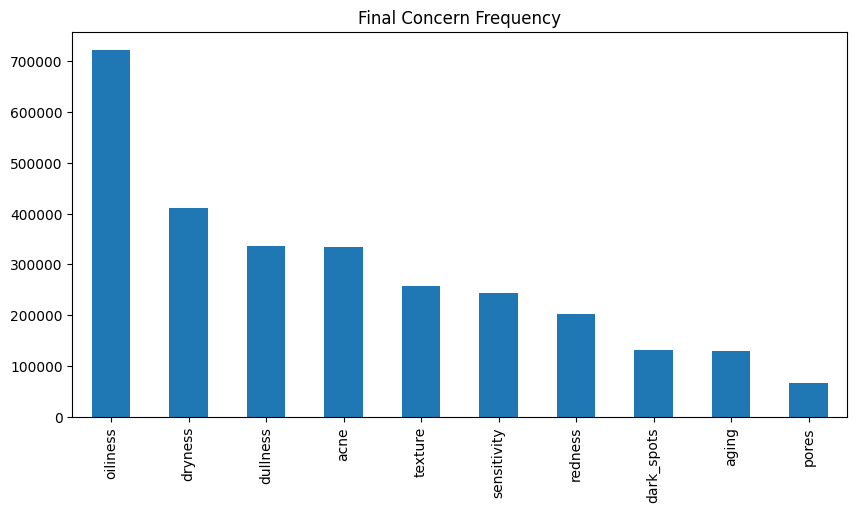

In [37]:
final_concern_freq.plot(kind="bar", figsize=(10, 5), title="Final Concern Frequency")

## 18. Define Effect Direction Patterns

Detecting the concern is not enough.
We also need to understand whether the product:
- helped the concern
- worsened the concern
- only mentions the concern as background context

In [38]:
positive_effect_patterns = [
    "helped", "helps", "helping",
    "good for", "great for", "works for",
    "improved", "improves", "improving",
    "reduced", "reduces", "reduce",
    "cleared", "clears", "clear up",
    "soothed", "soothes", "calmed", "calms",
    "hydrated", "hydrates", "moisturized", "moisturizes",
    "brightened", "brightens",
    "smoothed", "smooths",
    "minimized", "minimizes",
    "refined", "refines",
    "made my skin feel better"
]

negative_effect_patterns = [
    "caused", "causes",
    "made me", "gave me", "triggered",
    "worsened", "worsens",
    "dried out", "drying out",
    "irritated", "irritates",
    "burned", "burns", "burning",
    "stung", "stings", "stinging",
    "clogged", "clogs",
    "broke me out", "breaks me out",
    "left my skin", "made my skin",
    "made it worse"
]

target_only_patterns = [
    "i have", "i've had", "i am prone to",
    "my skin is", "for my skin",
    "for dry skin", "for oily skin", "for sensitive skin",
    "for acne prone skin", "for acne-prone skin",
    "i struggle with", "i deal with", "i have issues with"
]

## 19. Define Skin Area Patterns

Area detection is useful because a concern may affect different regions differently,
for example lips versus face.

In [39]:
area_dict = {
    "lips": ["lip", "lips"],
    "face": ["face", "skin", "my face", "facial skin"],
    "eyes": ["eye", "eyes", "under eye", "under-eye", "eyelid", "eyelids"],
    "cheeks": ["cheek", "cheeks"],
    "forehead": ["forehead"],
    "nose": ["nose"],
    "chin": ["chin"]
}

## 20. Extract Local Context Around the Matched Phrase

We do not want to assign effect labels based on the entire review.
Instead, we use a local token window around the matched phrase.

In [40]:
def get_local_context(text: str, phrase: str, window: int = 6) -> str:
    tokens = text.split()
    phrase_tokens = phrase.split()
    n = len(phrase_tokens)

    for i in range(len(tokens) - n + 1):
        candidate = " ".join(tokens[i:i+n])
        if candidate == phrase:
            start = max(0, i - window)
            end = min(len(tokens), i + n + window)
            return " ".join(tokens[start:end])

    return text

In [41]:
def detect_effect_label_from_context(context: str) -> str:
    context = context.lower()

    for pattern in positive_effect_patterns:
        if pattern in context:
            return "helped"

    for pattern in negative_effect_patterns:
        if pattern in context:
            return "worsened"

    for pattern in target_only_patterns:
        if pattern in context:
            return "target_only"

    return "unknown"

In [42]:
def detect_area_from_context(context: str, area_dict: Dict[str, List[str]]) -> str:
    context = context.lower()

    for area, keywords in area_dict.items():
        for kw in keywords:
            if kw in context:
                return area

    return "unknown"

## 21. Build a Phrase-Level Concern Match Table

We first build detailed concern rows from the rule-based matches.
This allows us to assign:
- effect_label
- area
- local_context

In [43]:
concern_match_records = []

for idx, row in df.iterrows():
    text = row["clean_text"]
    rule_based_matches = row["rule_based_matches"]

    for concern, matched_phrase in rule_based_matches:
        local_context = get_local_context(text, matched_phrase, window=6)
        effect_label = detect_effect_label_from_context(local_context)
        area = detect_area_from_context(local_context, area_dict)

        concern_match_records.append({
            "row_index": idx,
            "author_id": row.get("author_id"),
            "product_id": row.get("product_id"),
            "product_name_final": row.get("product_name_final"),
            "brand_name_final": row.get("brand_name_final"),
            "skin_type": row.get("skin_type"),
            "rating": row.get("rating"),
            "rating_category": row.get("rating_category"),
            "is_recommended": row.get("is_recommended"),
            "primary_category": row.get("primary_category"),
            "secondary_category": row.get("secondary_category"),
            "raw_text": row.get("raw_text"),
            "normalized_text": row.get("normalized_text"),
            "clean_text": row.get("clean_text"),
            "concern": concern,
            "matched_phrase": matched_phrase,
            "local_context": local_context,
            "effect_label": effect_label,
            "area": area,
            "matched_by_rule_based": 1
        })

In [44]:
rule_based_concern_df = pd.DataFrame(concern_match_records)
print("rule_based_concern_df shape:", rule_based_concern_df.shape)
rule_based_concern_df.head()

rule_based_concern_df shape: (1204825, 20)


,row_index,author_id,product_id,product_name_final,brand_name_final,skin_type,rating,rating_category,is_recommended,primary_category,secondary_category,raw_text,normalized_text,clean_text,concern,matched_phrase,local_context,effect_label,area,matched_by_rule_based
0,2,5061282401,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,dry,5,positive,1.0,Skincare,Lip Balms & Treatments,New Favorite Routine My review title says it all! I get so excited to get into bed and apply this lip mask. I do see a difference because I suffer from dry cracked lips. I drink a lot of water and...,new favorite routine my review title says it all! i get so excited to get into bed and apply this lip mask. i do see a difference because i suffer from dry cracked lips. i drink a lot of water and...,new favorite routine my review title says it all i get so excited to get into bed and apply this lip mask i do see a difference because i suffer from dry cracked lips i drink a lot of water and ap...,dryness,dry,a difference because i suffer from dry cracked lips i drink a lot,unknown,lips,1
1,3,6083038851,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,combination,5,positive,1.0,Skincare,Lip Balms & Treatments,Can't go wrong with any of them I’ve always loved this formula for a long time. I honestly don’t even use it for night time. I use it as an everyday lip balm. I love the texture. Gummy Bear is my ...,can't go wrong with any of them i’ve always loved this formula for a long time. i honestly don’t even use it for night time. i use it as an everyday lip balm. i love the texture. gummy bear is my ...,can t go wrong with any of them i ve always loved this formula for a long time i honestly don t even use it for night time i use it as an everyday lip balm i love the texture gummy bear is my seco...,texture,texture,everyday lip balm i love the texture gummy bear is my second most,unknown,lips,1
2,4,47056667835,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,combination,5,positive,1.0,Skincare,Lip Balms & Treatments,"A must have !!! If you have dry cracked lips, this is a must have. After a few weeks of use I have learned I will always have by my bedside. I thought it was a little expensive but a little goes a...","a must have !!! if you have dry cracked lips, this is a must have. after a few weeks of use i have learned i will always have by my bedside. i thought it was a little expensive but a little goes a...",a must have if you have dry cracked lips this is a must have after a few weeks of use i have learned i will always have by my bedside i thought it was a little expensive but a little goes a long w...,dryness,dry,a must have if you have dry cracked lips this is a must,unknown,lips,1
3,5,42802569154,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,normal,4,positive,1.0,Skincare,Lip Balms & Treatments,"Great! The scent isn’t my favourite but it works great! I put it on every night before I go to sleep and every morning I wake up with smooth, moisturizer and soft. Packaging is amazing as well","great! the scent isn’t my favourite but it works great! i put it on every night before i go to sleep and every morning i wake up with smooth, moisturizer and soft. packaging is amazing as well",great the scent isn t my favourite but it works great i put it on every night before i go to sleep and every morning i wake up with smooth moisturizer and soft packaging is amazing as well,aging,aging,great the scent isn t my favourite but it works great i put it on every night before i go to sleep and every morning i wake up with smooth moisturizer and soft packaging is amazing as well,unknown,unknown,1
4,6,6941883808,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,combination,2,negative,0.0,Skincare,Lip Balms & Treatments,"Dried my lips out and clogged my pores I’ll give this 2 stars for nice packaging and lovely scent. Upon initial application, it feels very nice. But as I continued t

## 22. Add Semantic-Only Concern Rows

Some concerns may only appear through semantic similarity.
These rows are weaker signals, so:
- matched_phrase is left empty
- effect_label defaults to unknown
- area defaults to unknown

In [45]:
semantic_records = []

for idx, row in df.iterrows():
    rule_based_concerns = set(row["rule_based_concerns"])
    semantic_concerns = set(row["semantic_concerns"])

    semantic_only = semantic_concerns - rule_based_concerns

    if len(semantic_only) == 0:
        continue

    for concern in semantic_only:
        semantic_records.append({
            "row_index": idx,
            "author_id": row.get("author_id"),
            "product_id": row.get("product_id"),
            "product_name_final": row.get("product_name_final"),
            "brand_name_final": row.get("brand_name_final"),
            "skin_type": row.get("skin_type"),
            "rating": row.get("rating"),
            "rating_category": row.get("rating_category"),
            "is_recommended": row.get("is_recommended"),
            "primary_category": row.get("primary_category"),
            "secondary_category": row.get("secondary_category"),
            "raw_text": row.get("raw_text"),
            "normalized_text": row.get("normalized_text"),
            "clean_text": row.get("clean_text"),
            "concern": concern,
            "matched_phrase": None,
            "local_context": row.get("clean_text"),
            "effect_label": "unknown",
            "area": "unknown",
            "matched_by_rule_based": 0
        })

In [46]:
semantic_only_df = pd.DataFrame(semantic_records)
print("semantic_only_df shape:", semantic_only_df.shape)
semantic_only_df.head()

semantic_only_df shape: (1628032, 20)


,row_index,author_id,product_id,product_name_final,brand_name_final,skin_type,rating,rating_category,is_recommended,primary_category,secondary_category,raw_text,normalized_text,clean_text,concern,matched_phrase,local_context,effect_label,area,matched_by_rule_based
0,1,31423088263,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,None,1,negative,0.0,Skincare,Lip Balms & Treatments,"Disappointed I bought this lip mask after reading the reviews and the hype. Unfortunately, it did not meet my expectations as vaseline petroleum jelly works way better for me.","disappointed i bought this lip mask after reading the reviews and the hype. unfortunately, it did not meet my expectations as vaseline petroleum jelly works way better for me.",disappointed i bought this lip mask after reading the reviews and the hype unfortunately it did not meet my expectations as vaseline petroleum jelly works way better for me,dryness,None,disappointed i bought this lip mask after reading the reviews and the hype unfortunately it did not meet my expectations as vaseline petroleum jelly works way better for me,unknown,unknown,0
1,1,31423088263,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,None,1,negative,0.0,Skincare,Lip Balms & Treatments,"Disappointed I bought this lip mask after reading the reviews and the hype. Unfortunately, it did not meet my expectations as vaseline petroleum jelly works way better for me.","disappointed i bought this lip mask after reading the reviews and the hype. unfortunately, it did not meet my expectations as vaseline petroleum jelly works way better for me.",disappointed i bought this lip mask after reading the reviews and the hype unfortunately it did not meet my expectations as vaseline petroleum jelly works way better for me,oiliness,None,disappointed i bought this lip mask after reading the reviews and the hype unfortunately it did not meet my expectations as vaseline petroleum jelly works way better for me,unknown,unknown,0
2,2,5061282401,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,dry,5,positive,1.0,Skincare,Lip Balms & Treatments,New Favorite Routine My review title says it all! I get so excited to get into bed and apply this lip mask. I do see a difference because I suffer from dry cracked lips. I drink a lot of water and...,new favorite routine my review title says it all! i get so excited to get into bed and apply this lip mask. i do see a difference because i suffer from dry cracked lips. i drink a lot of water and...,new favorite routine my review title says it all i get so excited to get into bed and apply this lip mask i do see a difference because i suffer from dry cracked lips i drink a lot of water and ap...,acne,None,new favorite routine my review title says it all i get so excited to get into bed and apply this lip mask i do see a difference because i suffer from dry cracked lips i drink a lot of water and ap...,unknown,unknown,0
3,2,5061282401,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,dry,5,positive,1.0,Skincare,Lip Balms & Treatments,New Favorite Routine My review title says it all! I get so excited to get into bed and apply this lip mask. I do see a difference because I suffer from dry cracked lips. I drink a lot of water and...,new favorite routine my review title says it all! i get so excited to get into bed and apply this lip mask. i do see a difference because i suffer from dry cracked lips. i drink a lot of water and...,new favorite routine my review title says it all i get so excited to get into bed and apply this lip mask i do see a difference because i suffer from dry cracked lips i drink a lot of water and ap...,oiliness,None,new favorite routine my review title says it all i get so excited to get into bed and apply this lip mask i do see a difference because i suffer from dry cracked lips i drink a lot of water and ap...,unknown,unknown,0
4,6,6941883808,P420652,Lip Sleeping Mask Intense Hydration with Vitamin 

## 23. Combine Rule-Based and Semantic Concern Rows

In [47]:
review_concern_level = pd.concat(
    [rule_based_concern_df, semantic_only_df],
    ignore_index=True
)

review_concern_level["matched_by_semantic"] = 1

print("review_concern_level shape:", review_concern_level.shape)
review_concern_level.head()

review_concern_level shape: (2832857, 21)


,row_index,author_id,product_id,product_name_final,brand_name_final,skin_type,rating,rating_category,is_recommended,primary_category,secondary_category,raw_text,normalized_text,clean_text,concern,matched_phrase,local_context,effect_label,area,matched_by_rule_based,matched_by_semantic
0,2,5061282401,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,dry,5,positive,1.0,Skincare,Lip Balms & Treatments,New Favorite Routine My review title says it all! I get so excited to get into bed and apply this lip mask. I do see a difference because I suffer from dry cracked lips. I drink a lot of water and...,new favorite routine my review title says it all! i get so excited to get into bed and apply this lip mask. i do see a difference because i suffer from dry cracked lips. i drink a lot of water and...,new favorite routine my review title says it all i get so excited to get into bed and apply this lip mask i do see a difference because i suffer from dry cracked lips i drink a lot of water and ap...,dryness,dry,a difference because i suffer from dry cracked lips i drink a lot,unknown,lips,1,1
1,3,6083038851,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,combination,5,positive,1.0,Skincare,Lip Balms & Treatments,Can't go wrong with any of them I’ve always loved this formula for a long time. I honestly don’t even use it for night time. I use it as an everyday lip balm. I love the texture. Gummy Bear is my ...,can't go wrong with any of them i’ve always loved this formula for a long time. i honestly don’t even use it for night time. i use it as an everyday lip balm. i love the texture. gummy bear is my ...,can t go wrong with any of them i ve always loved this formula for a long time i honestly don t even use it for night time i use it as an everyday lip balm i love the texture gummy bear is my seco...,texture,texture,everyday lip balm i love the texture gummy bear is my second most,unknown,lips,1,1
2,4,47056667835,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,combination,5,positive,1.0,Skincare,Lip Balms & Treatments,"A must have !!! If you have dry cracked lips, this is a must have. After a few weeks of use I have learned I will always have by my bedside. I thought it was a little expensive but a little goes a...","a must have !!! if you have dry cracked lips, this is a must have. after a few weeks of use i have learned i will always have by my bedside. i thought it was a little expensive but a little goes a...",a must have if you have dry cracked lips this is a must have after a few weeks of use i have learned i will always have by my bedside i thought it was a little expensive but a little goes a long w...,dryness,dry,a must have if you have dry cracked lips this is a must,unknown,lips,1,1
3,5,42802569154,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,normal,4,positive,1.0,Skincare,Lip Balms & Treatments,"Great! The scent isn’t my favourite but it works great! I put it on every night before I go to sleep and every morning I wake up with smooth, moisturizer and soft. Packaging is amazing as well","great! the scent isn’t my favourite but it works great! i put it on every night before i go to sleep and every morning i wake up with smooth, moisturizer and soft. packaging is amazing as well",great the scent isn t my favourite but it works great i put it on every night before i go to sleep and every morning i wake up with smooth moisturizer and soft packaging is amazing as well,aging,aging,great the scent isn t my favourite but it works great i put it on every night before i go to sleep and every morning i wake up with smooth moisturizer and soft packaging is amazing as well,unknown,unknown,1,1
4,6,6941883808,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,combination,2,negative,0.0,Skincare,Lip Balms & Treatments,"Dried my lips out and clogged my pores I’ll give this 2 stars for nice packaging and lovely scent. Upon initial application, it feels ver

## 24. Add Concern Confidence

Simple first-iteration confidence logic:
- rule-based row → stronger confidence
- semantic-only row → weaker confidence
- known effect label → stronger confidence
- matched phrase present → stronger confidence

In [48]:
def compute_concern_confidence(row) -> float:
    score = 0.0

    if row["matched_by_rule_based"] == 1:
        score += 0.6
    else:
        score += 0.3

    if row["effect_label"] != "unknown":
        score += 0.2

    if pd.notna(row["matched_phrase"]):
        score += 0.2

    return min(score, 1.0)

In [49]:
review_concern_level["concern_confidence"] = review_concern_level.apply(
    compute_concern_confidence,
    axis=1
)

review_concern_level[[
    "concern",
    "matched_phrase",
    "effect_label",
    "area",
    "matched_by_rule_based",
    "matched_by_semantic",
    "concern_confidence"
]].head(20)

,concern,matched_phrase,effect_label,area,matched_by_rule_based,matched_by_semantic,concern_confidence
0,dryness,dry,unknown,lips,1,1,0.8
1,texture,texture,unknown,lips,1,1,0.8
2,dryness,dry,unknown,lips,1,1,0.8
3,aging,aging,unknown,unknown,1,1,0.8
4,acne,pimple,worsened,lips,1,1,1.0
5,dryness,dry,unknown,lips,1,1,0.8
6,pores,pores,worsened,lips,1,1,1.0
7,aging,aging,worsened,lips,1,1,1.0
8,dryness,dry,helped,unknown,1,1,1.0
9,oiliness,shine,helped,lips,1,1,1.0


## 25. Remove Duplicate Concern Rows

A review may trigger the same concern multiple times.
We remove duplicate rows at the review-concern-effect-phrase level.

In [50]:
review_concern_level = review_concern_level.drop_duplicates(
    subset=["row_index", "concern", "effect_label", "matched_phrase"]
).copy()

print("review_concern_level shape after dedup:", review_concern_level.shape)

review_concern_level shape after dedup: (2832857, 22)


## 26. Inspect Effect and Area Distributions

In [51]:
review_concern_level["effect_label"].value_counts(dropna=False)

effect_label
unknown        2349125
target_only     219887
helped          191843
worsened         72002
Name: count, dtype: int64

In [52]:
review_concern_level["area"].value_counts(dropna=False)

area
unknown     2051502
face         708909
eyes          28905
lips          24320
cheeks         6983
nose           4578
forehead       4326
chin           3334
Name: count, dtype: int64

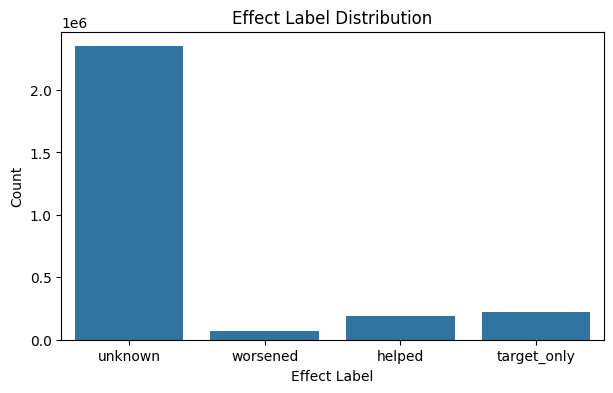

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7, 4))
sns.countplot(x="effect_label", data=review_concern_level)
plt.title("Effect Label Distribution")
plt.xlabel("Effect Label")
plt.ylabel("Count")
plt.show()

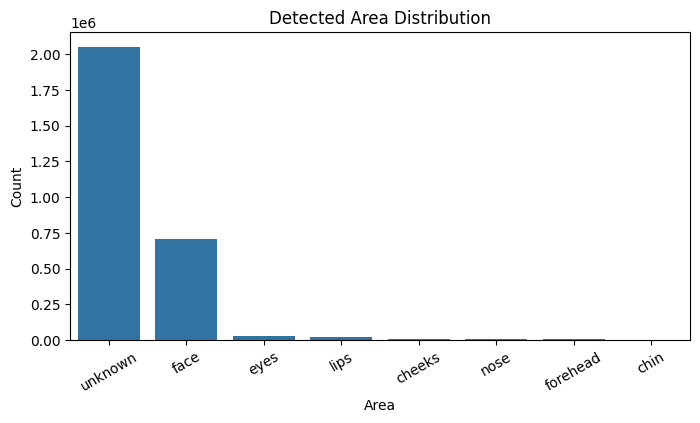

In [59]:
plt.figure(figsize=(8, 4))
sns.countplot(x="area", data=review_concern_level, order=review_concern_level["area"].value_counts().index)
plt.title("Detected Area Distribution")
plt.xlabel("Area")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

## 27. Build a Compact Review Text Feature Table

In [61]:
review_text_features = df[[
    "author_id",
    "product_id",
    "product_name_final",
    "brand_name_final",
    "rating",
    "rating_category",
    "is_recommended",
    "skin_type",
    "primary_category",
    "secondary_category",
    "review_title",
    "review_text",
    "raw_text",
    "normalized_text",
    "clean_text",
    "review_text_length",
    "raw_text_length",
    "has_title",
    "rule_based_concerns",
    "semantic_concerns",
    "final_concerns",
    "concern_count"
]].copy()

In [62]:
print("review_text_features shape:", review_text_features.shape)
review_text_features.head()

review_text_features shape: (1092743, 22)


,author_id,product_id,product_name_final,brand_name_final,rating,rating_category,is_recommended,skin_type,primary_category,secondary_category,review_title,review_text,raw_text,normalized_text,clean_text,review_text_length,raw_text_length,has_title,rule_based_concerns,semantic_concerns,final_concerns,concern_count
0,1741593524,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,5,positive,1.0,dry,Skincare,Cleansers,Taught me how to double cleanse!,I use this with the Nudestix “Citrus Clean Balm & Make-Up Melt“ to double cleanse and it has completely changed my skin (for the better). The make-up melt is oil based and removes all of your make...,Taught me how to double cleanse! I use this with the Nudestix “Citrus Clean Balm & Make-Up Melt“ to double cleanse and it has completely changed my skin (for the better). The make-up melt is oil b...,taught me how to double cleanse! i use this with the nudestix “citrus clean balm & make-up melt“ to double cleanse and it has completely changed my skin (for the better). the make-up melt is oil b...,taught me how to double cleanse i use this with the nudestix citrus clean balm make up melt to double cleanse and it has completely changed my skin for the better the make up melt is oil based and...,455,488,1,[],[],[],0
1,31423088263,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,1,negative,0.0,None,Skincare,Lip Balms & Treatments,Disappointed,"I bought this lip mask after reading the reviews and the hype. Unfortunately, it did not meet my expectations as vaseline petroleum jelly works way better for me.","Disappointed I bought this lip mask after reading the reviews and the hype. Unfortunately, it did not meet my expectations as vaseline petroleum jelly works way better for me.","disappointed i bought this lip mask after reading the reviews and the hype. unfortunately, it did not meet my expectations as vaseline petroleum jelly works way better for me.",disappointed i bought this lip mask after reading the reviews and the hype unfortunately it did not meet my expectations as vaseline petroleum jelly works way better for me,162,175,1,[],"[dryness, oiliness]","[dryness, oiliness]",2
2,5061282401,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,5,positive,1.0,dry,Skincare,Lip Balms & Treatments,New Favorite Routine,My review title says it all! I get so excited to get into bed and apply this lip mask. I do see a difference because I suffer from dry cracked lips. I drink a lot of water and apply lip balm daily...,New Favorite Routine My review title says it all! I get so excited to get into bed and apply this lip mask. I do see a difference because I suffer from dry cracked lips. I drink a lot of water and...,new favorite routine my review title says it all! i get so excited to get into bed and apply this lip mask. i do see a difference because i suffer from dry cracked lips. i drink a lot of water and...,new favorite routine my review title says it all i get so excited to get into bed and apply this lip mask i do see a difference because i suffer from dry cracked lips i drink a lot of water and ap...,272,293,1,[dryness],"[acne, dryness, oiliness]","[acne, dryness, oiliness]",3
3,6083038851,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,5,positive,1.0,combination,Skincare,Lip Balms & Treatments,Can't go wrong with any of them,I’ve always loved this formula for a long time. I honestly don’t even use it for night time. I use it as an everyday lip balm. I love the texture. Gummy Bear is my second most favourite scent. Gra...,Can't go wrong with any of them I’ve always loved this formula for a long time. I honestly don’t even use it for night time. I use it as an everyday lip balm. I love the texture. Gummy Bear is my ...,can't go wrong with any of them i’ve always loved this formula for a long time. i honestly don’t even use it for night time. i use it as an everyday lip balm. i love the texture. gummy bear is my ...,can t go wrong with any of them 

## 28. Inspect Final Output Samples

In [63]:
review_concern_level[[
    "clean_text",
    "concern",
    "matched_phrase",
    "local_context",
    "effect_label",
    "area",
    "concern_confidence"
]].sample(20, random_state=42)

,clean_text,concern,matched_phrase,local_context,effect_label,area,concern_confidence
540914,love it i have had problematic skin all my life large pores oily very acne prone starting to show some sun spots and hyper pigmentation and dry in spots in the winter these two products have start...,dryness,dry,sun spots and hyper pigmentation and dry in spots in the winter these,unknown,unknown,0.8
1989582,nice night facemask the product seems great so far i ve been using it since the past three weeks i ve noticed that my skin has broken out a little less and i have noticed a glue on my skin this pr...,dullness,None,nice night facemask the product seems great so far i ve been using it since the past three weeks i ve noticed that my skin has broken out a little less and i have noticed a glue on my skin this pr...,unknown,unknown,0.3
1046409,new holy grail i am so grateful i got to try this for free with tryitwithtopbox i used this with the firming serum and it is the complete package usually i have to put on lots of different product...,aging,firming,tryitwithtopbox i used this with the firming serum and it is the complete,unknown,unknown,0.8
397512,works very well with my sensitive skin smells earthy so if you re not into that just fair warning but it s not over powering for myself i love how easy this is to apply and take off unlike most ma...,sensitivity,sensitive,works very well with my sensitive skin smells earthy so if you,unknown,face,0.8
2556631,soooo fabulous this is my first lotion from lamer and i must say that its absolutely wonderful it feels sooooo good that make me feel better about the price lol the skin looks so hidrated after th...,oiliness,None,soooo fabulous this is my first lotion from lamer and i must say that its absolutely wonderful it feels sooooo good that make me feel better about the price lol the skin looks so hidrated after th...,unknown,unknown,0.3
728718,i loved it except i thought these products did mostly what they claim to do it hydrated my skin and made it look smoother and feel very hydrated and also gave it a natural looking dewy and or good...,redness,redness,also it claim to take away redness or at least less it and,unknown,unknown,0.8
640812,new formula changed the texture now it sucks i have incredibly dry skin and without a good exfoliant it builds up on my face i loved this stuff and it worked so well i used it for years it exfolia...,texture,texture,new formula changed the texture now it sucks i have incredibly,target_only,unknown,1.0
2252516,recommend this has made my skin look so much better i have red spots and it s helping brighten them to my natural skin color,acne,None,recommend this has made my skin look so much better i have red spots and it s helping brighten them to my natural skin color,unknown,unknown,0.3
217907,i love the texture of this toner and the light watermelon scent and the packaging is beautiful however after using the whole bottle i didn t notice any significant improvement or benefits to justi...,aging,aging,i love the texture of this toner and the light watermelon scent and the packaging is beautiful however after using the whole bottle i didn t notice any significant improvement or benefits to justi...,target_only,face,1.0
1064853,excellent smell i received this product to sample for a free sample program this product smells amazing and has many great skin benefits including vitamin e to nourish and strengthen skin coconut ...,oiliness,oily,was a little drying i have oily skin so it wasn t terrible,target_only,face,1.0


## 29. Save Outputs

In [65]:
review_text_features.to_parquet(PROCESSED_DIR / "review_text_features.parquet", index=False)
review_concern_level.to_parquet(PROCESSED_DIR / "review_concern_level.parquet", index=False)

print("Saved:")
print(PROCESSED_DIR / "review_text_features.parquet")
print(PROCESSED_DIR / "review_concern_level.parquet")

Saved:
../data/processed/review_text_features.parquet
../data/processed/review_concern_level.parquet


# Conclusion

This notebook created the first concern-aware and effect-aware NLP layer of the project.

We now have:
- review text prepared for downstream NLP
- rule-based concern extraction
- semantic concern enrichment
- final concern labels
- effect direction labels:
  - helped
  - worsened
  - target_only
  - unknown
- area detection
- a review-level concern table for later aggregation

## Next Step
The next notebook should:
- aggregate review-level signals to product-concern-level summaries
- compute concern-specific helped/worsened statistics
- prepare product-level ranking features for recommendation modeling